## CHEM6291 HW2 - Problem 2: Butler-Volmer Kinetics

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
F = 96485  # C/mol
R = 8.314  # J/(mol*K)
T = 298    # K
n = 1      # number of electrons (general example)

### Fundamental Equation

$$i = i_0 \left[ e^{\frac{\alpha nF\eta}{RT}} - e^{-\frac{(1-\alpha)nF\eta}{RT}} \right]$$

---

### (a) Effect of Transfer Coefficient $\alpha$

- **Large $\alpha$ (close to 1)**: Favors anodic process, curve becomes asymmetric
- **$\alpha = 0.5$**: Symmetric energy barriers (equal for cathodic and anodic processes)
- **Small $\alpha$ (<0.5)**: Favors cathodic direction

**Physical significance**: $\alpha$ reflects the sensitivity of the electrode reaction to electrode potential and determines the symmetry between anodic and cathodic processes.

---

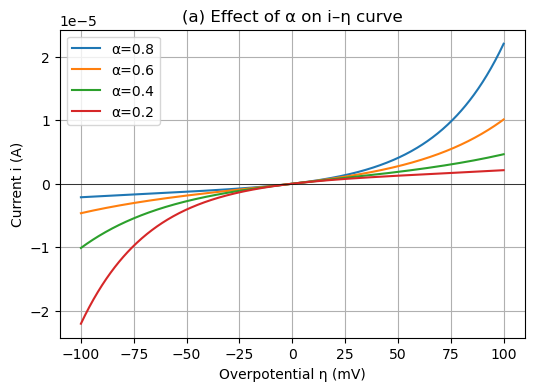

In [41]:
i0 = 1e-6  # 1 µA
alphas = [0.8, 0.6, 0.4, 0.2]

eta = np.linspace(-0.1, 0.1, 500)  # Overpotential in V

plt.figure(figsize=(6,4))
for alpha in alphas:
    i = i0*(np.exp(alpha*n*F*eta/(R*T)) - np.exp(-(1-alpha)*n*F*eta/(R*T)))
    plt.plot(eta*1000, i, label=f'α={alpha}')
plt.axhline(0, color='k', linewidth=0.5)
plt.xlabel('Overpotential η (mV)')
plt.ylabel('Current i (A)')
plt.title('(a) Effect of α on i–η curve')
plt.legend()
plt.grid(True)
plt.show()


### (b) Effect of Exchange Current Density $i_0$

- **Small $i_0$ (1 nA)**: Sluggish reaction kinetics (Hg-like surface for HER)
- **Large $i_0$ (1 A)**: Fast reaction kinetics (Pt surface with excellent HER activity)
- **Medium $i_0$ (1 μA, 1 mA)**: Moderate reaction rates

**Practical applications**:
- **Pt surface**: $i_0 \sim 1-10$ mA/cm², excellent HER catalyst
- **Hg surface**: $i_0 \sim 10^{-12}-10^{-9}$ A/cm², very poor HER catalyst

---


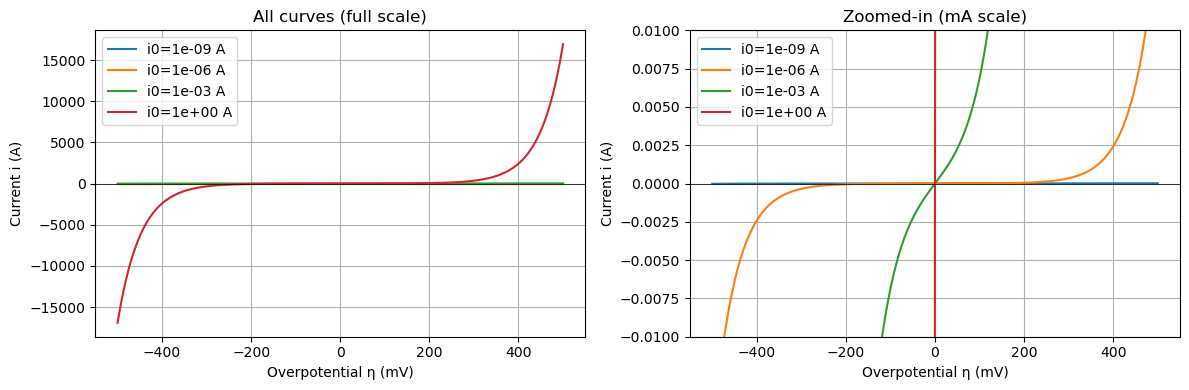

In [46]:
# (b) Effect of Exchange Current Density i0 - Full scale and Zoomed-in

i0_values = [1e-9, 1e-6, 1e-3, 1.0]  # A
alpha = 0.5

eta = np.linspace(-0.5, 0.5, 500)  # Overpotential in V

fig, axes = plt.subplots(1, 2, figsize=(12,4))

# (left) All curves together, full scale
for i0 in i0_values:
    i = i0*(np.exp(alpha*n*F*eta/(R*T)) - np.exp(-(1-alpha)*n*F*eta/(R*T)))
    axes[0].plot(eta*1000, i, label=f'i0={i0:.0e} A')
axes[0].axhline(0, color='k', linewidth=0.5)
axes[0].set_xlabel("Overpotential η (mV)")
axes[0].set_ylabel("Current i (A)")
axes[0].set_title("All curves (full scale)")
axes[0].legend()
axes[0].grid(True)

# (right) Zoom-in (mA region)
for i0 in i0_values:
    i = i0*(np.exp(alpha*n*F*eta/(R*T)) - np.exp(-(1-alpha)*n*F*eta/(R*T)))
    axes[1].plot(eta*1000, i, label=f'i0={i0:.0e} A')
axes[1].axhline(0, color='k', linewidth=0.5)
axes[1].set_ylim(-0.01, 0.01)  # Zoom into ±10 mA region
axes[1].set_xlabel("Overpotential η (mV)")
axes[1].set_ylabel("Current i (A)")
axes[1].set_title("Zoomed-in (mA scale)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


(c) Linear region (small \(\eta\))

Approximation:

$$i \approx i_0 \frac{nF}{RT}\eta$$

So,

$$R_{ct} = \frac{RT}{nFi_0}$$

For HER

$$R_{ct} = \frac{0.0257}{2 \times 96485 \times 10^{-3}} \approx 0.0133 \, \Omega$$

(d) Tafel region

Approx:

$$\eta = a + b \log i$$

with slope:

$$b = \frac{2.303RT}{\alpha nF}$$

- For the 1-electron RDS in the 4-electron ORR: slope = 120 mV/dec \((alpha = 0.5, n = 1)\).  
- 60 mV/dec → 2-electron involvement or higher \(alpha).  
- 30 mV/dec → very fast, but difficult to measure (mass transport dominates).  

### (e) $i / i_l - \eta$ Curves (Kinetic and Mass Transport Coupling)

**Modified equation**:

$$i = \frac{i_k i_l}{i_k + i_l}, \quad \text{where } i_k \text{ comes from Butler-Volmer equation}$$

**Three limiting cases**:

- **When $i_0 \ll i_l$**: Kinetic-controlled (reaction rate limited by electrode surface kinetics)
- **When $i_0 \gg i_l$**: Mass transport-controlled (reaction rate limited by reactant diffusion to electrode surface)
- **When $i_0 \sim i_l$**: Mixed control (interplay between kinetics and mass transport)

**Physical significance**: This equation describes the competition between reaction kinetics ($i_k$) and mass transport ($i_l$) in electrode processes. The actual current always takes the smaller of the two limiting values.

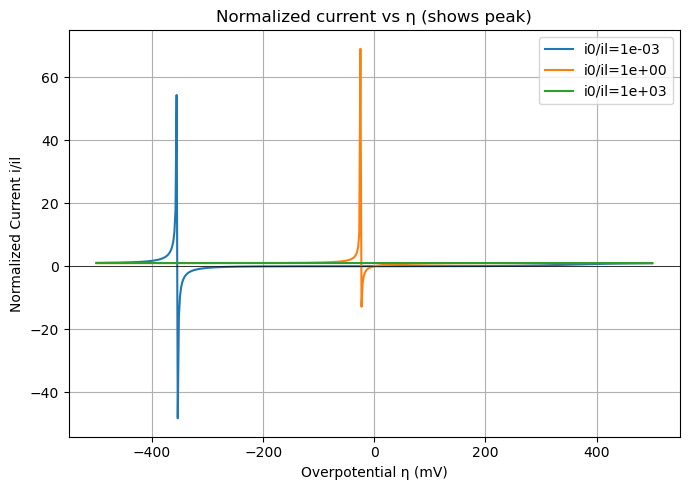

In [59]:
# ---------------------------
i0 = 1e-6   # Exchange current (A)
alpha = 0.5 # Charge transfer coefficient
n = 1       # Number of electrons
F = 96485   # Faraday constant (C/mol)
R = 8.314   # Gas constant (J/mol/K)
T = 298     # Temperature (K)
eta = np.linspace(-0.5, 0.5, 500)  # Overpotential range (V)

# i0/il ratios
i_l_values = [i0/1e-3, i0/1, i0/1e3]

# ---------------------------
# Only plot normalized current (right plot)
# ---------------------------
plt.figure(figsize=(7,5))

for i_l in i_l_values:
    # Butler-Volmer kinetic current
    i_k = i0*(np.exp(alpha*n*F*eta/(R*T)) - np.exp(-(1-alpha)*n*F*eta/(R*T)))
    # Overall current including mass transport limitation
    i = (i_k*i_l)/(i_k+i_l)
    plt.plot(eta*1000, i/i_l, label=f'i0/il={i0/i_l:.0e}')

# Horizontal line at zero
plt.axhline(0, color='k', linewidth=0.5)

# Labels and title
plt.xlabel("Overpotential η (mV)")
plt.ylabel("Normalized Current i/il")
plt.title("Normalized current vs η (shows peak)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()